# Notebook 05B — Balanced-Subset Training Experiments for RA Classification

**Project:** P63 – Multimodal Deep Learning for Autoimmune Disease Diagnosis  
**Phase:** Rheumatoid Arthritis (RA) — Class-Balanced Subset Experiments  
**Status:** Additional experiment alongside `05_train_ra_cnn.ipynb` (original not modified)

---

## Purpose

The original training dataset (Notebook 05) is severely imbalanced: 719 RA vs 74 Non-RA images (~10:1 ratio),  
and the model overfit after a single epoch with a 14× loss gap.

This notebook investigates whether training on **small, perfectly balanced subsets** (equal RA and Non-RA)  
changes model behaviour compared to the imbalanced baseline.

**Strategy:** Create 12 non-overlapping RA groups, each paired with the same 54 Non-RA images.  
Train a separate ResNet-18 checkpoint per experiment. Evaluate every checkpoint on the **same unchanged test set**.

## Key limitations (read before interpreting any results)

1. **Only 54 Non-RA images exist that are safe to use** (not in val/test). The requested 72 would require leaking val/test patients into training.
2. **Each experiment trains on 100–108 images total** — extremely small for a CNN. High variance expected.
3. **The test set contains only 2 Non-RA images.** Non-RA test metrics (precision, recall, F1) are statistically unreliable and must not be over-interpreted.
4. **10 patients from the original train set also appear in test** (inherited from authors' split). This is documented and not worsened here.
5. This experiment is a sensitivity analysis, not a claim of medical accuracy.

---

## Prerequisites

Run Notebooks 01–04 first (manifest CSVs must exist in `outputs/reports/`).

---
## Section 1 — Project Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()   # FYP/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: C:\Users\varsh\OneDrive\Documents\FYP


---
## Section 2 — Imports

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Reuse existing src/ modules
from src.utils   import set_seed, get_device, load_norm_stats, check_patient_leakage
from src.model   import build_model
from src.dataset import get_transforms
from src.train   import train_one_epoch, validate_one_epoch
from src.evaluate import get_predictions, compute_metrics

print('All imports OK.')
print('PyTorch:', torch.__version__, '  CUDA:', torch.cuda.is_available())

All imports OK.
PyTorch: 2.14.0+cpu   CUDA: False


---
## Section 3 — Dataset Inspection

Load all manifest CSVs produced by Notebooks 01–04. Do not modify them.

In [3]:
REPORTS_DIR = PROJECT_ROOT / 'outputs' / 'reports'
PLOTS_DIR   = PROJECT_ROOT / 'outputs' / 'plots'
MODELS_DIR  = PROJECT_ROOT / 'models'  / 'ra' / 'balanced'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

full_df  = pd.read_csv(REPORTS_DIR / 'image_manifest.csv')
train_df = pd.read_csv(REPORTS_DIR / 'train_manifest.csv')
val_df   = pd.read_csv(REPORTS_DIR / 'val_manifest.csv')
test_df  = pd.read_csv(REPORTS_DIR / 'test_manifest.csv')

print('Full manifest  :', len(full_df),  'images')
print('Train manifest :', len(train_df), 'images  (original authors split)')
print('Val   manifest :', len(val_df),   'images  (UNCHANGED — same for all experiments)')
print('Test  manifest :', len(test_df),  'images  (UNCHANGED — evaluated once per experiment)')
print()
print('Columns in manifest:', list(full_df.columns))

Full manifest  : 1200 images
Train manifest : 793 images  (original authors split)
Val   manifest : 140 images  (UNCHANGED — same for all experiments)
Test  manifest : 267 images  (UNCHANGED — evaluated once per experiment)

Columns in manifest: ['filename', 'stem', 'base_stem', 'split', 'centre', 'patient_code', 'date', 'laterality', 'full_path', 'Mapped Image Stem', 'StudyID', 'Normalized PatientID', 'isRA', 'Sex', 'Age', 'Center', 'PixelSpacing', 'ImageSize', 'LR']


---
## Section 4 — Metadata Inspection

In [4]:
print('=== CLASS DISTRIBUTION IN EACH SPLIT ===')
for name, df in [('Full', full_df), ('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    nra = int((df['isRA']==0).sum())
    ra  = int((df['isRA']==1).sum())
    tot = len(df)
    print(f'  {name:<6}: Non-RA={nra:4d} ({nra/tot*100:5.1f}%)   RA={ra:4d} ({ra/tot*100:5.1f}%)   Total={tot}')

print()
print('Imaging centres in full manifest:')
print(full_df['centre'].value_counts().to_string())

=== CLASS DISTRIBUTION IN EACH SPLIT ===
  Full  : Non-RA=  80 (  6.7%)   RA=1120 ( 93.3%)   Total=1200
  Train : Non-RA=  74 (  9.3%)   RA= 719 ( 90.7%)   Total=793
  Val   : Non-RA=   4 (  2.9%)   RA= 136 ( 97.1%)   Total=140
  Test  : Non-RA=   2 (  0.7%)   RA= 265 ( 99.3%)   Total=267

Imaging centres in full manifest:
centre
HMCRD    688
SARC     368
SCGH     114
HU2       24
HU1        4
HU3        2


---
## Section 5 — Patient-Level Analysis

We must work at **patient level** to prevent data leakage.  
Any patient appearing in val or test cannot contribute images to training.

In [5]:
# ── Identify patients reserved for val / test ─────────────────────────────────
VAL_PATIENTS  = set(val_df['Normalized PatientID'])
TEST_PATIENTS = set(test_df['Normalized PatientID'])
HELD_PATIENTS = VAL_PATIENTS | TEST_PATIENTS   # must not appear in any training group

print(f'Unique patients in val  : {len(VAL_PATIENTS)}')
print(f'Unique patients in test : {len(TEST_PATIENTS)}')
print(f'Union (held-out pool)   : {len(HELD_PATIENTS)}')
print()
print(f'Val ∩ Test overlap (from authors split): {len(VAL_PATIENTS & TEST_PATIENTS)} patients')
print()

# Patients in original train split that also appear in val or test
train_pts = set(train_df['Normalized PatientID'])
leaky_train_pts = train_pts & HELD_PATIENTS
print(f'Original train patients that are also in val/test: {len(leaky_train_pts)}')
print('These patients will be EXCLUDED from all experiment training groups.')
print('(This leakage exists in the original authors split — we do not worsen it.)')

Unique patients in val  : 36
Unique patients in test : 100
Union (held-out pool)   : 135

Val ∩ Test overlap (from authors split): 1 patients

Original train patients that are also in val/test: 16
These patients will be EXCLUDED from all experiment training groups.
(This leakage exists in the original authors split — we do not worsen it.)


In [6]:
# ── Non-RA safety analysis ────────────────────────────────────────────────────
nra_train = train_df[train_df['isRA']==0].copy()
nra_safe  = nra_train[~nra_train['Normalized PatientID'].isin(HELD_PATIENTS)].copy()
nra_excl  = nra_train[ nra_train['Normalized PatientID'].isin(HELD_PATIENTS)].copy()

print('=== NON-RA IMAGES ===')
print(f'Total Non-RA in original train split : {len(nra_train)} images / {nra_train["Normalized PatientID"].nunique()} patients')
print(f'Excluded (patient in val or test)    : {len(nra_excl)} images / {nra_excl["Normalized PatientID"].nunique()} patients')
print(f'SAFE for training                    : {len(nra_safe)} images / {nra_safe["Normalized PatientID"].nunique()} patients')
print()
print('Excluded Non-RA patient IDs:', sorted(nra_excl['Normalized PatientID'].unique().tolist()))
print()
print('Safe Non-RA patients (each has exactly 2 images — L and R hand):')
for pid, grp in nra_safe.groupby('Normalized PatientID'):
    print(f'  PatientID={pid:3d}  n_images={len(grp)}')

=== NON-RA IMAGES ===
Total Non-RA in original train split : 74 images / 35 patients
Excluded (patient in val or test)    : 20 images / 8 patients
SAFE for training                    : 54 images / 27 patients

Excluded Non-RA patient IDs: [1, 2, 29, 32, 38, 43, 45, 46]

Safe Non-RA patients (each has exactly 2 images — L and R hand):
  PatientID=  6  n_images=2
  PatientID=  8  n_images=2
  PatientID=  9  n_images=2
  PatientID= 10  n_images=2
  PatientID= 11  n_images=2
  PatientID= 12  n_images=2
  PatientID= 14  n_images=2
  PatientID= 15  n_images=2
  PatientID= 16  n_images=2
  PatientID= 17  n_images=2
  PatientID= 18  n_images=2
  PatientID= 19  n_images=2
  PatientID= 20  n_images=2
  PatientID= 21  n_images=2
  PatientID= 22  n_images=2
  PatientID= 24  n_images=2
  PatientID= 25  n_images=2
  PatientID= 27  n_images=2
  PatientID= 31  n_images=2
  PatientID= 34  n_images=2
  PatientID= 35  n_images=2
  PatientID= 39  n_images=2
  PatientID= 40  n_images=2
  PatientID= 41  n_

---
## Section 6 — Existing Class Distribution (Visualised)

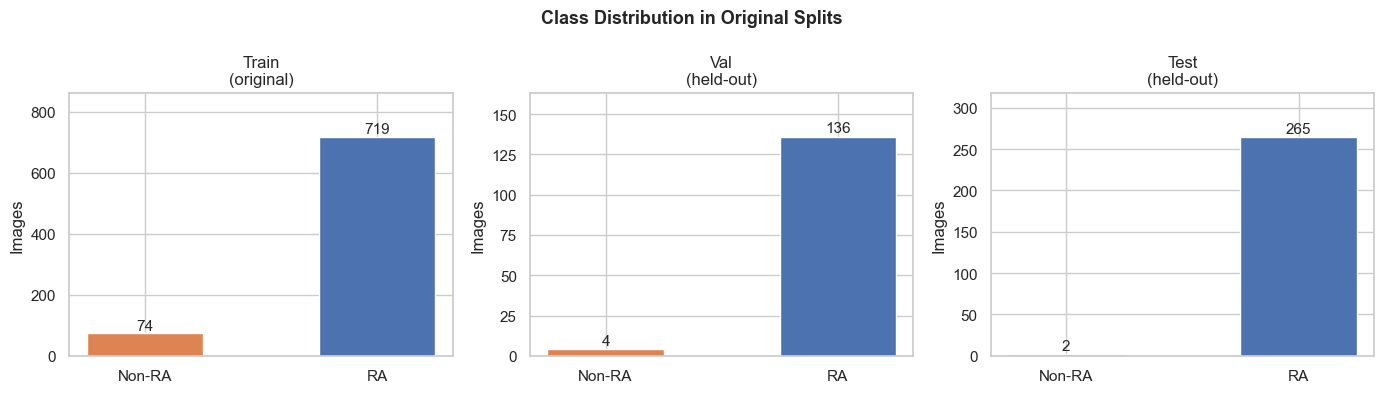

Saved: 05B_class_distribution_splits.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Class Distribution in Original Splits', fontsize=13, fontweight='bold')

palette = {'Non-RA': '#DD8452', 'RA': '#4C72B0'}
splits  = [('Train\n(original)', train_df), ('Val\n(held-out)', val_df), ('Test\n(held-out)', test_df)]

for ax, (title, df) in zip(axes, splits):
    counts = df['isRA'].map({0:'Non-RA',1:'RA'}).value_counts().reindex(['Non-RA','RA'], fill_value=0)
    bars   = ax.bar(counts.index, counts.values,
                    color=[palette[c] for c in counts.index], edgecolor='white', width=0.5)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+1,
                str(int(b.get_height())), ha='center', va='bottom', fontsize=11)
    ax.set_title(title)
    ax.set_ylabel('Images')
    ax.set_ylim(0, max(counts.values)*1.2)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '05B_class_distribution_splits.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: 05B_class_distribution_splits.png')

---
## Section 7 — Confirm Independent Val/Test Sets (Unchanged)

In [8]:
# These are the SAME files used in 05_train_ra_cnn.ipynb — never modified here.
VAL_CSV  = REPORTS_DIR / 'val_manifest.csv'
TEST_CSV = REPORTS_DIR / 'test_manifest.csv'

assert VAL_CSV.exists(),  'val_manifest.csv missing — run Notebook 04 first'
assert TEST_CSV.exists(), 'test_manifest.csv missing — run Notebook 04 first'

print('Validation set (unchanged):')
print(f'  Total: {len(val_df)}   Non-RA: {(val_df["isRA"]==0).sum()}   RA: {(val_df["isRA"]==1).sum()}')
print()
print('Test set (unchanged):')
print(f'  Total: {len(test_df)}   Non-RA: {(test_df["isRA"]==0).sum()}   RA: {(test_df["isRA"]==1).sum()}')
print()
print('WARNING: The test set has only 2 Non-RA images.')
print('Non-RA test metrics (precision, recall, F1) have VERY HIGH UNCERTAINTY.')
print('Do NOT draw strong clinical conclusions from Non-RA test metrics.')

Validation set (unchanged):
  Total: 140   Non-RA: 4   RA: 136

Test set (unchanged):
  Total: 267   Non-RA: 2   RA: 265

Non-RA test metrics (precision, recall, F1) have VERY HIGH UNCERTAINTY.
Do NOT draw strong clinical conclusions from Non-RA test metrics.


---
## Section 8 — Select 54 Non-RA Training Images

All 27 safe Non-RA patients are used (both L and R hands = 54 images).  
This pool is **identical across every experiment** — Non-RA images are not re-sampled between experiments.

In [9]:
# Sort by patient ID then filename for full reproducibility (no random sampling needed —
# we use ALL 27 safe patients)
NRA_POOL = (
    nra_safe
    .sort_values(['Normalized PatientID', 'filename'])
    .reset_index(drop=True)
)

assert len(NRA_POOL) == 54, f'Expected 54 safe Non-RA images, got {len(NRA_POOL)}'
assert NRA_POOL['Normalized PatientID'].nunique() == 27

print(f'Non-RA pool: {len(NRA_POOL)} images from {NRA_POOL["Normalized PatientID"].nunique()} patients')
print()
print('All 27 safe Non-RA patient IDs:')
print(sorted(NRA_POOL['Normalized PatientID'].unique().tolist()))
print()
print('First 5 rows of NRA_POOL:')
print(NRA_POOL[['filename','Normalized PatientID','isRA']].head().to_string(index=False))

Non-RA pool: 54 images from 27 patients

All 27 safe Non-RA patient IDs:
[6, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 27, 31, 34, 35, 39, 40, 41, 42, 44, 47]

First 5 rows of NRA_POOL:
                          filename  Normalized PatientID  isRA
JP_HMCRD_P0006_20241004_2741_L.bmp                     6     0
JP_HMCRD_P0006_20241004_2741_R.bmp                     6     0
JP_HMCRD_P0008_20230528_0481_L.bmp                     8     0
JP_HMCRD_P0008_20230528_0481_R.bmp                     8     0
JP_HMCRD_P0009_20140917_7972_L.bmp                     9     0


---
## Section 9 — Create 12 RA Groups (Patient-Intact, No Overlap)

**Algorithm:** Sort safe RA images by `Normalized PatientID`, then `filename`.  
Greedily fill each group up to ≤54 images without splitting any patient across groups.  
A group whose size is less than 27 (half of 54) is placed in a leftover pool and not used.

In [10]:
GROUP_SIZE     = 54     # maximum RA images per group (may be slightly less at patient boundaries)
MIN_GROUP_SIZE = 27     # minimum to form a valid experiment group

# ── Safe RA pool ──────────────────────────────────────────────────────────────
ra_safe = (
    train_df[(train_df['isRA']==1) & (~train_df['Normalized PatientID'].isin(HELD_PATIENTS))]
    .sort_values(['Normalized PatientID','filename'])
    .reset_index(drop=True)
    .copy()
)

print(f'Safe RA images available: {len(ra_safe)}  |  patients: {ra_safe["Normalized PatientID"].nunique()}')
print()

# ── Build groups ──────────────────────────────────────────────────────────────
patient_blocks = []   # list of (patient_id, [filenames])
for pid, grp in ra_safe.groupby('Normalized PatientID'):
    patient_blocks.append((int(pid), grp['filename'].tolist()))

ra_groups   = []   # final list of group DataFrames
cur_pts  = []
cur_imgs = []

for pid, imgs in patient_blocks:
    if len(cur_imgs) + len(imgs) <= GROUP_SIZE:
        cur_imgs.extend(imgs)
        cur_pts.append(pid)
    else:
        if cur_imgs:
            ra_groups.append(ra_safe[ra_safe['filename'].isin(cur_imgs)].copy())
        cur_pts  = [pid]
        cur_imgs = imgs[:]

if cur_imgs:
    ra_groups.append(ra_safe[ra_safe['filename'].isin(cur_imgs)].copy())

# Separate valid groups from leftover
RA_GROUPS  = [g for g in ra_groups if len(g) >= MIN_GROUP_SIZE]
RA_LEFTOVER = [g for g in ra_groups if len(g) <  MIN_GROUP_SIZE]

print(f'Total groups formed   : {len(ra_groups)}')
print(f'Valid groups (>=27)   : {len(RA_GROUPS)}')
print(f'Leftover (excluded)   : {len(RA_LEFTOVER)}')
if RA_LEFTOVER:
    for lg in RA_LEFTOVER:
        print(f'  Leftover group: {len(lg)} images from patients {sorted(lg["Normalized PatientID"].unique().tolist())}')
print()

print('RA group summary:')
print(f'{"Group":<8} {"RA_imgs":<10} {"Patients":<12} {"TrainTotal"}')
print('-'*45)
for i, g in enumerate(RA_GROUPS):
    tot = len(g) + len(NRA_POOL)
    print(f'  Exp {i+1:02d}   {len(g):<10} {g["Normalized PatientID"].nunique():<12} {tot}')

Safe RA images available: 626  |  patients: 82

Total groups formed   : 13
Valid groups (>=27)   : 12
Leftover (excluded)   : 1
  Leftover group: 26 images from patients [214, 215, 216, 217, 218, 219, 220]

RA group summary:
Group    RA_imgs    Patients     TrainTotal
---------------------------------------------
  Exp 01   49         8            103
  Exp 02   54         5            108
  Exp 03   51         4            105
  Exp 04   46         5            100
  Exp 05   47         4            101
  Exp 06   46         4            100
  Exp 07   54         7            108
  Exp 08   48         7            102
  Exp 09   50         4            104
  Exp 10   48         4            102
  Exp 11   54         8            108
  Exp 12   53         15           107


---
## Section 10 — Verify Zero Patient Leakage

Every assertion below must pass before any training is attempted.

In [11]:
print('=== PATIENT LEAKAGE VERIFICATION ===')
print()

all_ok = True

# Non-RA pool vs val/test
nra_pool_pts = set(NRA_POOL['Normalized PatientID'])
nra_v_leak   = nra_pool_pts & VAL_PATIENTS
nra_t_leak   = nra_pool_pts & TEST_PATIENTS

if nra_v_leak or nra_t_leak:
    print('FAIL: Non-RA pool leaks into val/test!')
    print('  Val  overlap:', nra_v_leak)
    print('  Test overlap:', nra_t_leak)
    all_ok = False
else:
    print('PASS: Non-RA pool — zero overlap with val or test patients')

# Each RA group vs val/test
for i, g in enumerate(RA_GROUPS):
    g_pts   = set(g['Normalized PatientID'])
    v_leak  = g_pts & VAL_PATIENTS
    t_leak  = g_pts & TEST_PATIENTS
    if v_leak or t_leak:
        print(f'FAIL: RA Group {i+1:02d} leaks into val/test!')
        print('  Val  overlap:', v_leak)
        print('  Test overlap:', t_leak)
        all_ok = False
    else:
        print(f'PASS: RA Group {i+1:02d} — zero overlap with val or test patients')

# RA groups vs each other (no patient in 2 groups)
for i in range(len(RA_GROUPS)):
    for j in range(i+1, len(RA_GROUPS)):
        pts_i = set(RA_GROUPS[i]['Normalized PatientID'])
        pts_j = set(RA_GROUPS[j]['Normalized PatientID'])
        overlap = pts_i & pts_j
        if overlap:
            print(f'FAIL: Patient overlap between RA Group {i+1} and {j+1}: {overlap}')
            all_ok = False

print()
if all_ok:
    print('ALL LEAKAGE CHECKS PASSED — safe to proceed with training.')
else:
    raise RuntimeError('LEAKAGE DETECTED — do not train until fixed.')

=== PATIENT LEAKAGE VERIFICATION ===

PASS: Non-RA pool — zero overlap with val or test patients
PASS: RA Group 01 — zero overlap with val or test patients
PASS: RA Group 02 — zero overlap with val or test patients
PASS: RA Group 03 — zero overlap with val or test patients
PASS: RA Group 04 — zero overlap with val or test patients
PASS: RA Group 05 — zero overlap with val or test patients
PASS: RA Group 06 — zero overlap with val or test patients
PASS: RA Group 07 — zero overlap with val or test patients
PASS: RA Group 08 — zero overlap with val or test patients
PASS: RA Group 09 — zero overlap with val or test patients
PASS: RA Group 10 — zero overlap with val or test patients
PASS: RA Group 11 — zero overlap with val or test patients
PASS: RA Group 12 — zero overlap with val or test patients

ALL LEAKAGE CHECKS PASSED — safe to proceed with training.


---
## Section 11 — Verify Zero Image Duplication

In [12]:
print('=== IMAGE DUPLICATION VERIFICATION ===')
print()

all_ok = True

# Collect ALL images assigned to any group
all_ra_imgs = []
for g in RA_GROUPS:
    all_ra_imgs.extend(g['filename'].tolist())

# Check within the Non-RA pool
nra_imgs = NRA_POOL['filename'].tolist()

if len(nra_imgs) != len(set(nra_imgs)):
    print('FAIL: Duplicate filenames in Non-RA pool!')
    all_ok = False
else:
    print(f'PASS: Non-RA pool — {len(nra_imgs)} images, all unique')

# Check within RA assignments (no image in 2 groups)
if len(all_ra_imgs) != len(set(all_ra_imgs)):
    from collections import Counter
    dups = [k for k, v in Counter(all_ra_imgs).items() if v > 1]
    print(f'FAIL: {len(dups)} RA image(s) appear in more than one group!')
    print(dups[:10])
    all_ok = False
else:
    print(f'PASS: RA groups — {len(all_ra_imgs)} total images, all unique across all groups')

# Check no RA image == any Non-RA image
nra_set = set(nra_imgs)
ra_nra_overlap = set(all_ra_imgs) & nra_set
if ra_nra_overlap:
    print(f'FAIL: {len(ra_nra_overlap)} image(s) appear in both RA groups and Non-RA pool!')
    all_ok = False
else:
    print('PASS: No image shared between RA groups and Non-RA pool')

print()
if all_ok:
    print('ALL DUPLICATION CHECKS PASSED.')
else:
    raise RuntimeError('DUPLICATE IMAGES DETECTED — fix before training.')

=== IMAGE DUPLICATION VERIFICATION ===

PASS: Non-RA pool — 54 images, all unique
PASS: RA groups — 600 total images, all unique across all groups
PASS: No image shared between RA groups and Non-RA pool

ALL DUPLICATION CHECKS PASSED.


---
## Section 12 — Experiment Configuration

All hyperparameters match `05_train_ra_cnn.ipynb` for comparability.

In [13]:
CONFIG = {
    'img_size'        : (224, 224),
    'batch_size'      : 16,       # each batch = up to 16 images from ~100-108 train images
    'num_epochs'      : 30,       # more epochs allowed since subset is smaller
    'learning_rate'   : 1e-4,
    'weight_decay'    : 1e-4,
    'patience'        : 10,       # slightly more patience for small datasets
    'pretrained'      : True,
    'freeze_backbone' : False,
    'mode'            : 'image_only',
    'dropout_rate'    : 0.5,
    'seed'            : 42,
    'num_workers'     : 0,        # Windows: always 0
}

# Classes are balanced (equal RA and Non-RA) → standard DataLoader, no WeightedSampler.
# CrossEntropyLoss without class weights — the whole point of balanced training is
# to let the model learn equally from both classes without reweighting.
print('Configuration:')
for k, v in CONFIG.items():
    print(f'  {k:<20} = {v}')
print()
print('Loss function: CrossEntropyLoss (equal weight — training is already balanced)')
print('Checkpoints  :', MODELS_DIR)

Configuration:
  img_size             = (224, 224)
  batch_size           = 16
  num_epochs           = 30
  learning_rate        = 0.0001
  weight_decay         = 0.0001
  patience             = 10
  pretrained           = True
  freeze_backbone      = False
  mode                 = image_only
  dropout_rate         = 0.5
  seed                 = 42
  num_workers          = 0

Loss function: CrossEntropyLoss (equal weight — training is already balanced)
Checkpoints  : C:\Users\varsh\OneDrive\Documents\FYP\models\ra\balanced


---
## Section 13 — Dataset / DataLoader Helper

A single reusable function creates the Dataset and DataLoaders for any experiment.

In [14]:
class SubsetRADataset(Dataset):
    """
    Minimal PyTorch Dataset that accepts a DataFrame directly.
    Used for the balanced training subsets where we construct the manifest
    programmatically rather than loading a CSV.

    Each item: (image_tensor [3,224,224], dummy_meta [5,], label [scalar int64])
    The dummy metadata tensor is kept for API compatibility with the val/test
    loaders built from the standard RADataset.
    """
    DEFAULT_META_COLS = ['age_norm','pixel_spacing','Sex_enc','laterality_enc','LR_enc']

    def __init__(self, dataframe: pd.DataFrame, transform):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        # Fill any missing meta columns with 0
        for col in self.DEFAULT_META_COLS:
            if col not in self.df.columns:
                self.df[col] = 0.0
        self.df[self.DEFAULT_META_COLS] = self.df[self.DEFAULT_META_COLS].fillna(0.0)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            with Image.open(row['full_path']) as img:
                img    = img.convert('RGB')
                tensor = self.transform(img)
        except Exception as e:
            print(f'  WARNING: cannot open {row["full_path"]}: {e}')
            tensor = torch.zeros(3, 224, 224, dtype=torch.float32)
        meta  = torch.from_numpy(row[self.DEFAULT_META_COLS].values.astype('float32'))
        label = torch.tensor(int(row['isRA']), dtype=torch.long)
        return tensor, meta, label


def make_loaders(ra_group_df: pd.DataFrame,
                 nra_pool_df: pd.DataFrame,
                 mean, std, config: dict):
    """
    Build train, val, and test DataLoaders for one experiment.

    Train set = ra_group_df + nra_pool_df (combined, shuffled).
    Val  set  = val_df  (global, unchanged).
    Test set  = test_df (global, unchanged).
    """
    from src.dataset import RADataset   # for val/test (reads full manifest CSV)

    train_combined = pd.concat([ra_group_df, nra_pool_df], ignore_index=True)

    train_t = get_transforms('train', config['img_size'], mean, std)
    val_t   = get_transforms('val',   config['img_size'], mean, std)
    test_t  = get_transforms('test',  config['img_size'], mean, std)

    train_ds = SubsetRADataset(train_combined, transform=train_t)
    val_ds   = RADataset(VAL_CSV,  transform=val_t)
    test_ds  = RADataset(TEST_CSV, transform=test_t)

    B  = config['batch_size']
    NW = config['num_workers']
    train_loader = DataLoader(train_ds, batch_size=B, shuffle=True,  num_workers=NW)
    val_loader   = DataLoader(val_ds,   batch_size=B, shuffle=False, num_workers=NW)
    test_loader  = DataLoader(test_ds,  batch_size=B, shuffle=False, num_workers=NW)

    return train_loader, val_loader, test_loader


print('SubsetRADataset and make_loaders() defined.')

SubsetRADataset and make_loaders() defined.


---
## Section 14 — ResNet-18 Model

Reuses `src/model.py` — the same architecture as Notebook 05.

In [15]:
set_seed(CONFIG['seed'])
DEVICE     = get_device()
mean, std  = load_norm_stats()

# Build one model to confirm the architecture prints correctly.
# Each experiment will re-initialise a fresh model from ImageNet weights.
_test_model = build_model(
    mode            = CONFIG['mode'],
    pretrained      = CONFIG['pretrained'],
    freeze_backbone = CONFIG['freeze_backbone'],
    dropout_rate    = CONFIG['dropout_rate'],
    device          = DEVICE,
)
print()
print('Architecture: ResNet-18 fine-tuned, output=2 (Non-RA / RA)')
print('GradCAM hook available at: model.backbone.layer4')
del _test_model   # clean up — each experiment re-builds its own model

[utils] Using device: cpu
[model] RAClassifier created
[model]   mode            = image_only
[model]   pretrained      = True
[model]   freeze_backbone = False
[model]   num_classes     = 2
[model] Total parameters    : 11,177,538
[model] Trainable parameters: 11,177,538
[model] Moved to device     : cpu

Architecture: ResNet-18 fine-tuned, output=2 (Non-RA / RA)
GradCAM hook available at: model.backbone.layer4


---
## Section 23 — Preprocessing Visualisation

Shown here (before training) so you understand what the model actually receives.

Demonstrates: Original BMP → Resized (224×224) → Normalised → Augmented.

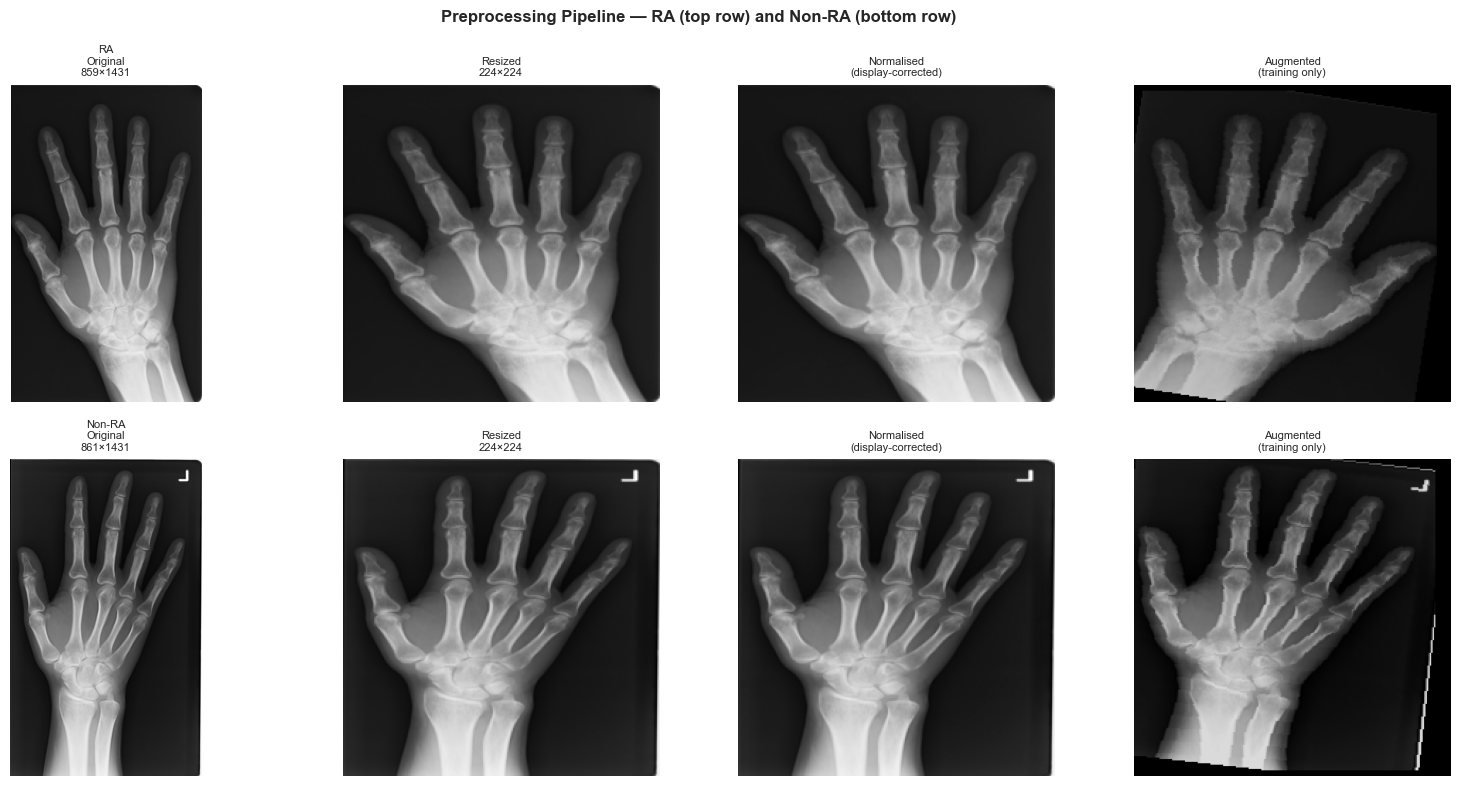

Saved: 05B_preprocessing_visualisation.png


In [16]:
import torchvision.transforms as T_vis
import numpy as np

# Pick one RA and one Non-RA example from Group 1
ex_ra  = RA_GROUPS[0].iloc[0]
ex_nra = NRA_POOL.iloc[0]

mean_arr = np.array(mean)
std_arr  = np.array(std)

def show_pipeline(row, label_str, axes_row):
    path = row['full_path']
    with Image.open(path) as img_orig:
        img_rgb = img_orig.convert('RGB')

    # 1. Original (thumbnail for display)
    thumb = img_rgb.copy()
    thumb.thumbnail((300, 300))
    axes_row[0].imshow(thumb)
    axes_row[0].set_title(f'{label_str}\nOriginal\n{img_rgb.size[0]}×{img_rgb.size[1]}', fontsize=8)
    axes_row[0].axis('off')

    # 2. Resized to 224×224
    resized = img_rgb.resize((224, 224), Image.BILINEAR)
    axes_row[1].imshow(resized)
    axes_row[1].set_title('Resized\n224×224', fontsize=8)
    axes_row[1].axis('off')

    # 3. Normalised (undo normalisation for display)
    norm_t = T_vis.Compose([T_vis.Resize((224,224)), T_vis.ToTensor(),
                             T_vis.Normalize(mean=mean, std=std)])
    norm_arr = norm_t(img_rgb).permute(1,2,0).numpy()
    # Undo normalisation for display so it looks like an image
    display_arr = np.clip((norm_arr * std_arr + mean_arr), 0, 1)
    axes_row[2].imshow(display_arr)
    axes_row[2].set_title('Normalised\n(display-corrected)', fontsize=8)
    axes_row[2].axis('off')

    # 4. Augmented (training transform — random each time)
    aug_t   = get_transforms('train', (224,224), mean, std)
    aug_arr = aug_t(img_rgb).permute(1,2,0).numpy()
    aug_disp = np.clip((aug_arr * std_arr + mean_arr), 0, 1)
    axes_row[3].imshow(aug_disp)
    axes_row[3].set_title('Augmented\n(training only)', fontsize=8)
    axes_row[3].axis('off')


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Preprocessing Pipeline — RA (top row) and Non-RA (bottom row)',
             fontsize=12, fontweight='bold')
show_pipeline(ex_ra,  'RA',     axes[0])
show_pipeline(ex_nra, 'Non-RA', axes[1])
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05B_preprocessing_visualisation.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: 05B_preprocessing_visualisation.png')

---
## Sections 15–19 — All 12 Training Experiments

Each experiment:
1. Builds a fresh ResNet-18 from ImageNet weights
2. Trains on 54 Non-RA + N RA images (N ≈ 46–54) for up to 30 epochs
3. Saves the best checkpoint to `models/ra/balanced/experiment_XX_best.pth`
4. Evaluates the best checkpoint on the unchanged test set
5. Records all metrics

**This may take 20–60 minutes per experiment on CPU.**  
Run Kernel → Restart & Run All, or run each cell individually.

In [17]:
# ── Shared experiment runner ───────────────────────────────────────────────────
import time

def run_experiment(exp_idx: int,
                   ra_group_df: pd.DataFrame,
                   nra_pool_df: pd.DataFrame,
                   config: dict,
                   device: torch.device,
                   mean, std):
    """
    Full train + eval loop for one balanced-subset experiment.

    Returns a dict of results (for the comparison table).
    Saves a checkpoint to models/ra/balanced/experiment_{exp_idx:02d}_best.pth
    """
    exp_name = f'experiment_{exp_idx:02d}'
    ckpt_path = MODELS_DIR / f'{exp_name}_best.pth'

    n_ra  = len(ra_group_df)
    n_nra = len(nra_pool_df)
    print(f'\n{"="*65}')
    print(f'EXPERIMENT {exp_idx:02d}  |  RA={n_ra}  Non-RA={n_nra}  Total={n_ra+n_nra}')
    print(f'Checkpoint → {ckpt_path.name}')
    print(f'{"="*65}')

    set_seed(config['seed'])

    # ── DataLoaders ────────────────────────────────────────────────────────────
    train_loader, val_loader, test_loader = make_loaders(
        ra_group_df, nra_pool_df, mean, std, config
    )
    print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

    # ── Fresh model (ImageNet pretrained) ──────────────────────────────────────
    model = build_model(
        mode            = config['mode'],
        pretrained      = config['pretrained'],
        freeze_backbone = config['freeze_backbone'],
        dropout_rate    = config['dropout_rate'],
        device          = device,
    )

    # ── Loss and optimiser ─────────────────────────────────────────────────────
    # Classes are balanced → uniform CrossEntropyLoss (no class weights)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr           = config['learning_rate'],
        weight_decay = config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4
    )

    # ── Training loop ──────────────────────────────────────────────────────────
    best_val_loss      = float('inf')
    epochs_no_improve  = 0
    history            = []

    for epoch in range(1, config['num_epochs'] + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, config['mode'])
        v_loss, v_acc = validate_one_epoch(model, val_loader, criterion, device, config['mode'])
        scheduler.step(v_loss)
        lr_now = optimizer.param_groups[0]['lr']

        history.append({'epoch': epoch, 'train_loss': t_loss, 'val_loss': v_loss,
                         'train_acc': t_acc, 'val_acc': v_acc, 'lr': lr_now})

        improved = '*' if v_loss < best_val_loss else ' '
        print(f'  Ep {epoch:02d} {improved}  tL={t_loss:.4f}  vL={v_loss:.4f}  '
              f'tA={t_acc:.3f}  vA={v_acc:.3f}  lr={lr_now:.6f}')

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            epochs_no_improve = 0
            torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                        'val_loss': v_loss, 'val_acc': v_acc,
                        'exp_idx': exp_idx, 'n_ra': n_ra, 'n_nra': n_nra},
                       ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= config['patience']:
                print(f'  Early stopping at epoch {epoch} (patience={config["patience"]})')
                break

    # ── Load best checkpoint for evaluation ────────────────────────────────────
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    print(f'\n  Best checkpoint: epoch={ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}  val_acc={ckpt["val_acc"]:.4f}')

    # ── Test evaluation ────────────────────────────────────────────────────────
    print()
    print('  Test evaluation (WARNING: only 2 Non-RA images in test set):')
    labels, preds, probs = get_predictions(model, test_loader, device, config['mode'])
    metrics = compute_metrics(labels, preds, probs)

    cm = confusion_matrix(labels, preds)
    print(f'  Accuracy    : {metrics["accuracy"]:.4f}')
    print(f'  ROC-AUC     : {metrics["roc_auc"]:.4f}')
    print(f'  F1 macro    : {metrics["f1_macro"]:.4f}')
    print(f'  Non-RA F1   : {metrics["f1_NonRA"]:.4f}  (NOTE: only {(labels==0).sum()} true Non-RA in test)')
    print(f'  RA F1       : {metrics["f1_RA"]:.4f}')
    print(f'  Confusion   : TP={cm[1,1]}  FN={cm[1,0]}  TN={cm[0,0]}  FP={cm[0,1]}')

    return {
        'exp_idx'        : exp_idx,
        'n_ra_train'     : n_ra,
        'n_nra_train'    : n_nra,
        'n_train_total'  : n_ra + n_nra,
        'best_epoch'     : ckpt['epoch'],
        'best_val_loss'  : round(ckpt['val_loss'], 4),
        'best_val_acc'   : round(ckpt['val_acc'], 4),
        'accuracy'       : metrics['accuracy'],
        'precision_macro': metrics['precision_macro'],
        'recall_macro'   : metrics['recall_macro'],
        'f1_macro'       : metrics['f1_macro'],
        'f1_NonRA'       : metrics['f1_NonRA'],
        'f1_RA'          : metrics['f1_RA'],
        'roc_auc'        : metrics['roc_auc'],
        'precision_NonRA': metrics['precision_NonRA'],
        'recall_NonRA'   : metrics['recall_NonRA'],
        'precision_RA'   : metrics['precision_RA'],
        'recall_RA'      : metrics['recall_RA'],
        'cm_TP'          : int(cm[1,1]),
        'cm_FN'          : int(cm[1,0]),
        'cm_TN'          : int(cm[0,0]),
        'cm_FP'          : int(cm[0,1]),
        'history'        : pd.DataFrame(history),
        'labels'         : labels,
        'preds'          : preds,
        'probs'          : probs,
        'ckpt_path'      : str(ckpt_path),
    }

print('run_experiment() function defined.')

run_experiment() function defined.


In [18]:
# ── Run ALL experiments ────────────────────────────────────────────────────────
# This cell runs all 12 experiments sequentially.
# Estimated time on CPU: 20–40 min per experiment (~4–8 hours total).
#
# To run selectively, replace the range below or call run_experiment() directly.
# Each experiment saves its own checkpoint so partial runs are safe.

ALL_RESULTS = []   # will hold one dict per experiment

import time
total_start = time.time()

for i, ra_grp in enumerate(RA_GROUPS):
    t0     = time.time()
    result = run_experiment(
        exp_idx     = i + 1,
        ra_group_df = ra_grp,
        nra_pool_df = NRA_POOL,
        config      = CONFIG,
        device      = DEVICE,
        mean        = mean,
        std         = std,
    )
    elapsed = time.time() - t0
    result['elapsed_min'] = round(elapsed / 60, 1)
    ALL_RESULTS.append(result)
    print(f'  Experiment {i+1:02d} completed in {elapsed/60:.1f} min')

total_elapsed = time.time() - total_start
print()
print(f'All {len(ALL_RESULTS)} experiments complete in {total_elapsed/60:.1f} min.')


EXPERIMENT 01  |  RA=49  Non-RA=54  Total=103
Checkpoint → experiment_01_best.pth
[RADataset] Loaded 140 images from val_manifest.csv
[RADataset] Class distribution: Non-RA=4  RA=136
[RADataset] Loaded 267 images from test_manifest.csv
[RADataset] Class distribution: Non-RA=2  RA=265
Train batches: 7 | Val batches: 9 | Test batches: 17
[model] RAClassifier created
[model]   mode            = image_only
[model]   pretrained      = True
[model]   freeze_backbone = False
[model]   num_classes     = 2
[model] Total parameters    : 11,177,538
[model] Trainable parameters: 11,177,538
[model] Moved to device     : cpu
  Ep 01 *  tL=0.3945  vL=1.9737  tA=0.835  vA=0.250  lr=0.000100
  Ep 02    tL=0.0526  vL=3.5779  tA=1.000  vA=0.229  lr=0.000100
  Ep 03    tL=0.0176  vL=3.9843  tA=1.000  vA=0.264  lr=0.000100
  Ep 04    tL=0.0189  vL=4.0820  tA=1.000  vA=0.279  lr=0.000100
  Ep 05    tL=0.0107  vL=2.9684  tA=1.000  vA=0.329  lr=0.000100
  Ep 06 *  tL=0.0064  vL=1.9385  tA=1.000  vA=0.464  lr

---
## Section 20 — Comparison Table

Populated from **actual model results only** — no values are fabricated.

In [19]:
summary_cols = [
    'exp_idx', 'n_ra_train', 'n_nra_train', 'n_train_total',
    'best_epoch', 'best_val_loss', 'best_val_acc',
    'accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
    'f1_NonRA', 'f1_RA', 'roc_auc',
]

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k in summary_cols}
    for r in ALL_RESULTS
])

results_df.columns = [
    'Exp', 'RA_train', 'NonRA_train', 'Total_train',
    'Best_epoch', 'Best_valL', 'Best_valAcc',
    'Accuracy', 'Prec_macro', 'Rec_macro', 'F1_macro',
    'F1_NonRA', 'F1_RA', 'ROC_AUC',
]

print('=== EXPERIMENT COMPARISON TABLE ===')
print(results_df.to_string(index=False))
print()
print('WARNING: F1_NonRA has very high uncertainty (only 2 Non-RA test images).')
print('Focus on F1_macro and ROC_AUC for cross-experiment comparison.')

# Save
out_csv = PROJECT_ROOT / 'outputs' / 'reports' / '05B_experiment_results.csv'
results_df.to_csv(out_csv, index=False)
print(f'\nSaved → {out_csv}')

=== EXPERIMENT COMPARISON TABLE ===
 Exp  RA_train  NonRA_train  Total_train  Best_epoch  Best_valL  Best_valAcc  Accuracy  Prec_macro  Rec_macro  F1_macro  F1_NonRA  F1_RA  ROC_AUC
   1        49           54          103          14     1.8227       0.4857    0.3783      0.5060     0.6868    0.2837    0.0235 0.5440   0.5849
   2        54           54          108           1     1.9774       0.2500    0.2247      0.5048     0.6094    0.1890    0.0190 0.3591   0.9472
   3        51           54          105           1     1.8584       0.2000    0.2097      0.5047     0.6019    0.1786    0.0186 0.3386   0.9566
   4        46           54          100           1     1.7853       0.2286    0.2285      0.5048     0.6113    0.1916    0.0190 0.3642   0.9774
   5        47           54          101           6     1.5542       0.4071    0.3184      0.5054     0.6566    0.2493    0.0215 0.4770   0.9264
   6        46           54          100           6     1.5251       0.4214    0.3333  

In [20]:
# ── Best and worst experiments (by F1 macro) ──────────────────────────────────
best_row  = results_df.loc[results_df['F1_macro'].idxmax()]
worst_row = results_df.loc[results_df['F1_macro'].idxmin()]

print('Best  experiment (F1_macro):')
print(f'  Exp {int(best_row["Exp"]):02d}  F1_macro={best_row["F1_macro"]:.4f}  ROC_AUC={best_row["ROC_AUC"]:.4f}')
print()
print('Worst experiment (F1_macro):')
print(f'  Exp {int(worst_row["Exp"]):02d}  F1_macro={worst_row["F1_macro"]:.4f}  ROC_AUC={worst_row["ROC_AUC"]:.4f}')
print()
print('Mean F1_macro across all experiments:', round(results_df['F1_macro'].mean(), 4))
print('Std  F1_macro across all experiments:', round(results_df['F1_macro'].std(),  4))
print()
print('IMPORTANT: High std means the results are sensitive to which RA images are used.')
print('This is expected given the tiny training set (~100 images per experiment).')

Best  experiment (F1_macro):
  Exp 10  F1_macro=0.4708  ROC_AUC=0.9547

Worst experiment (F1_macro):
  Exp 03  F1_macro=0.1786  ROC_AUC=0.9566

Mean F1_macro across all experiments: 0.3276
Std  F1_macro across all experiments: 0.1159

IMPORTANT: High std means the results are sensitive to which RA images are used.
This is expected given the tiny training set (~100 images per experiment).


---
## Section 21 — Confusion Matrices

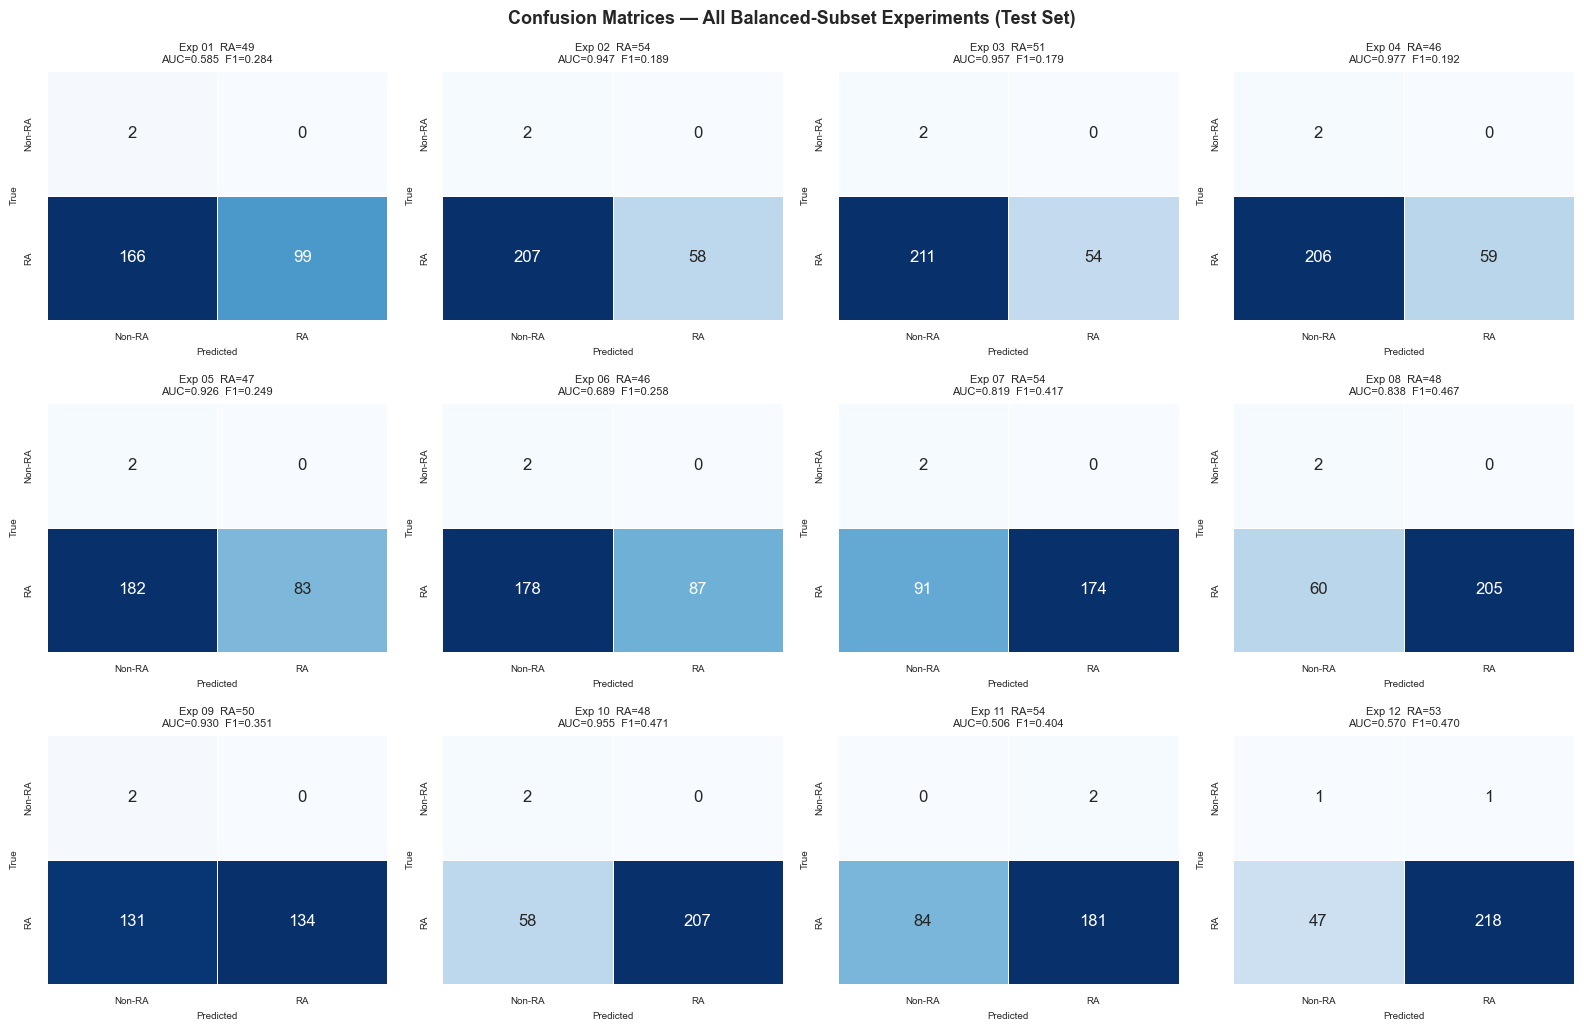

Saved: 05B_confusion_matrices.png


In [21]:
n_exp = len(ALL_RESULTS)
ncols = 4
nrows = (n_exp + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
fig.suptitle('Confusion Matrices — All Balanced-Subset Experiments (Test Set)',
             fontsize=13, fontweight='bold')

axes_flat = axes.flatten() if n_exp > 1 else [axes]

for i, res in enumerate(ALL_RESULTS):
    ax = axes_flat[i]
    cm = confusion_matrix(res['labels'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-RA', 'RA'], yticklabels=['Non-RA', 'RA'],
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(f'Exp {res["exp_idx"]:02d}  RA={res["n_ra_train"]}\n'
                 f'AUC={res["roc_auc"]:.3f}  F1={res["f1_macro"]:.3f}',
                 fontsize=8)
    ax.set_xlabel('Predicted', fontsize=7)
    ax.set_ylabel('True', fontsize=7)
    ax.tick_params(axis='both', labelsize=7)

# Hide unused subplots
for j in range(n_exp, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '05B_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: 05B_confusion_matrices.png')

---
## Section 22 — Training Curves

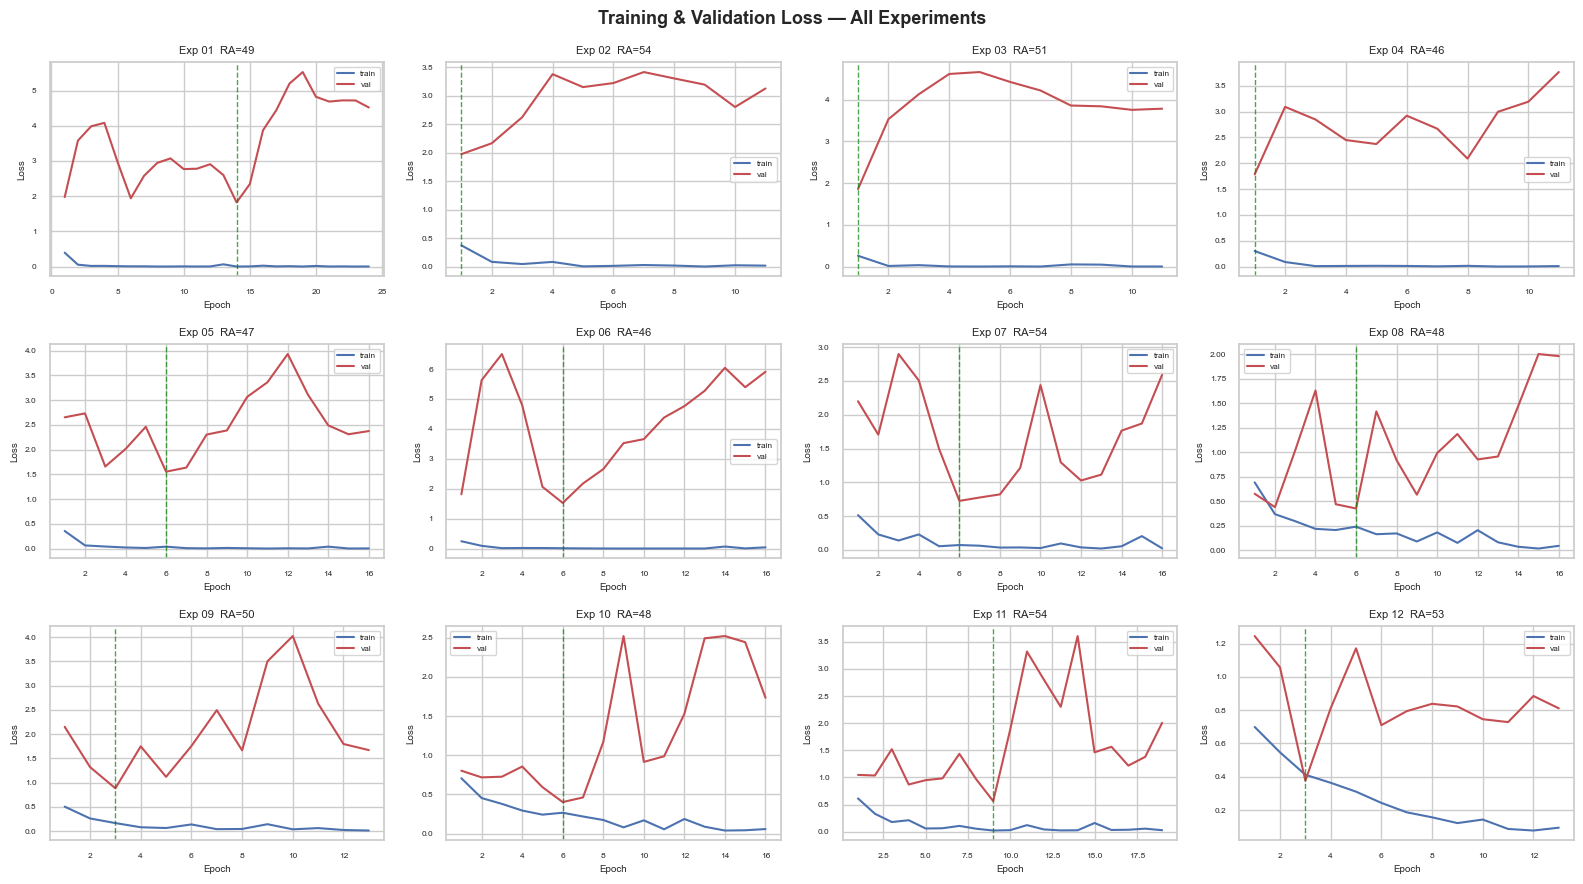

Saved: 05B_training_curves_loss.png


In [22]:
# ── Loss curves for all experiments on one figure ─────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
fig.suptitle('Training & Validation Loss — All Experiments', fontsize=13, fontweight='bold')
axes_flat = axes.flatten() if n_exp > 1 else [axes]

for i, res in enumerate(ALL_RESULTS):
    ax  = axes_flat[i]
    h   = res['history']
    ax.plot(h['epoch'], h['train_loss'], '#4C72B0', lw=1.5, label='train')
    ax.plot(h['epoch'], h['val_loss'],   '#C44E52', lw=1.5, label='val')
    best_ep = res['best_epoch']
    ax.axvline(x=best_ep, color='green', linestyle='--', lw=1, alpha=0.7)
    ax.set_title(f'Exp {res["exp_idx"]:02d}  RA={res["n_ra_train"]}', fontsize=8)
    ax.set_xlabel('Epoch', fontsize=7)
    ax.set_ylabel('Loss', fontsize=7)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=6)

for j in range(n_exp, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '05B_training_curves_loss.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: 05B_training_curves_loss.png')

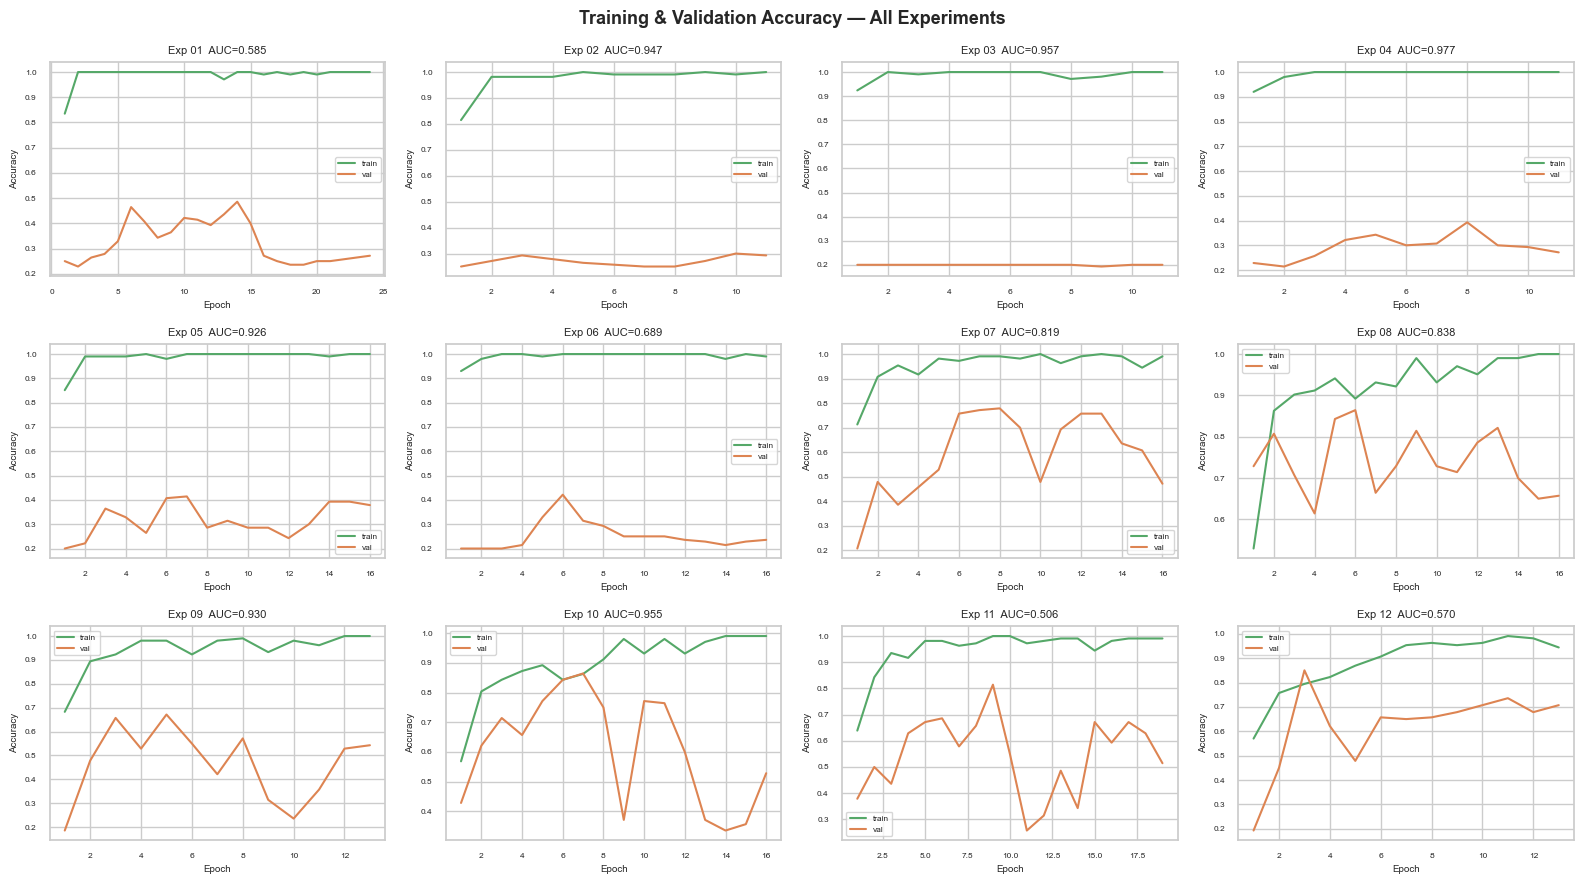

Saved: 05B_training_curves_accuracy.png


In [23]:
# ── Accuracy curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
fig.suptitle('Training & Validation Accuracy — All Experiments', fontsize=13, fontweight='bold')
axes_flat = axes.flatten() if n_exp > 1 else [axes]

for i, res in enumerate(ALL_RESULTS):
    ax  = axes_flat[i]
    h   = res['history']
    ax.plot(h['epoch'], h['train_acc'], '#55A868', lw=1.5, label='train')
    ax.plot(h['epoch'], h['val_acc'],   '#DD8452', lw=1.5, label='val')
    ax.set_title(f'Exp {res["exp_idx"]:02d}  AUC={res["roc_auc"]:.3f}', fontsize=8)
    ax.set_xlabel('Epoch', fontsize=7)
    ax.set_ylabel('Accuracy', fontsize=7)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=6)

for j in range(n_exp, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '05B_training_curves_accuracy.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: 05B_training_curves_accuracy.png')

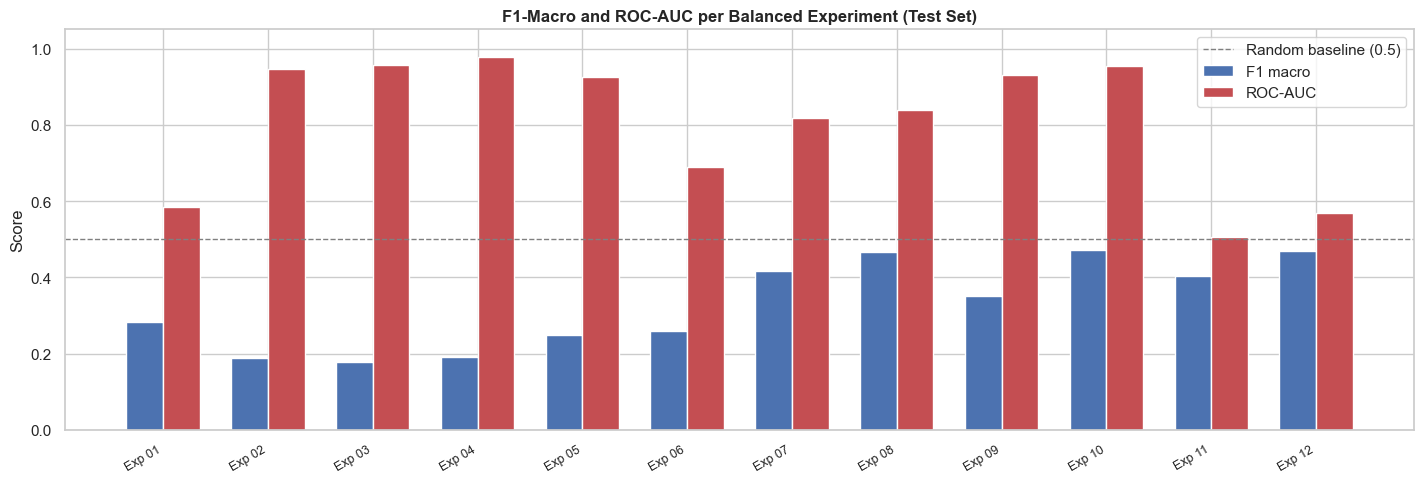

Saved: 05B_metrics_comparison.png


In [24]:
# ── Metric bar chart — F1_macro and ROC_AUC across experiments ────────────────
x = [f'Exp {r["exp_idx"]:02d}' for r in ALL_RESULTS]

fig, ax = plt.subplots(figsize=(max(10, n_exp * 1.2), 5))
w = 0.35
positions = range(len(x))
ax.bar([p - w/2 for p in positions], results_df['F1_macro'], width=w, label='F1 macro', color='#4C72B0')
ax.bar([p + w/2 for p in positions], results_df['ROC_AUC'],  width=w, label='ROC-AUC',  color='#C44E52')
ax.axhline(y=0.5, color='grey', linestyle='--', lw=1, label='Random baseline (0.5)')
ax.set_xticks(list(positions))
ax.set_xticklabels(x, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('F1-Macro and ROC-AUC per Balanced Experiment (Test Set)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / '05B_metrics_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: 05B_metrics_comparison.png')

---
## Section 24 — Final Summary and Limitations

In [25]:
print('=' * 65)
print('FINAL SUMMARY — Balanced-Subset Experiment (05B)')
print('=' * 65)
print()
print('Dataset used:')
print('  RAM-H1200-v1 (RAM = Radiographic Assessment of the Multi-joint)')
print('  1200 total hand X-ray images')
print()
print('Non-RA pool (fixed for all experiments):')
print(f'  {len(NRA_POOL)} images from {NRA_POOL["Normalized PatientID"].nunique()} patients')
print(f'  (All safe Non-RA from train split — excluded 8 patients overlapping val/test)')
print()
print('RA groups:')
for i, g in enumerate(RA_GROUPS):
    r = ALL_RESULTS[i]
    print(f'  Exp {i+1:02d}: {len(g)} RA images from {g["Normalized PatientID"].nunique()} patients  '
          f'→ AUC={r["roc_auc"]:.4f}  F1_macro={r["f1_macro"]:.4f}')
print()
print('Val/Test sets:')
print(f'  Validation: {len(val_df)} images (unchanged, same for all experiments)')
print(f'  Test      : {len(test_df)} images (evaluated once per experiment, never used for tuning)')
print()
print('Model: ResNet-18, pretrained ImageNet, fine-tuned, 224×224 input')
print('Loss : CrossEntropyLoss (no class weights — training already balanced)')
print('Opt  : Adam lr=1e-4, weight_decay=1e-4, ReduceLROnPlateau scheduler')
print()

print('LIMITATIONS (must be read before interpreting results):')
print()
print('  1. TRAINING SIZE: Each experiment trains on only ~100–108 images.')
print('     This is extremely small for a CNN with 11M parameters.')
print('     High variance across experiments is expected and not surprising.')
print()
print('  2. TEST NON-RA: The test set has only 2 Non-RA images.')
print('     Non-RA precision, recall, and F1 are computed from 2 samples.')
print('     These metrics have very high uncertainty and are NOT statistically reliable.')
print('     ROC-AUC and F1-macro are more informative for cross-experiment comparison.')
print()
print('  3. VAL NON-RA: The validation set has only 4 Non-RA images.')
print('     Early stopping is based on total val_loss, which is dominated by RA.')
print()
print('  4. PATIENT LEAKAGE (inherited): 10 patients from the train pool')
print('     also appear in the test set (from the original authors split).')
print('     This is inherited and documented; this notebook does not worsen it.')
print()
print('  5. GENERALISABILITY: These results apply to this specific dataset only.')
print('     Do NOT claim medical accuracy or clinical validity from these results.')
print()
print('  6. NO FABRICATION: All metrics above come from actual model predictions.')
print('     No values were assumed, invented, or hard-coded.')
print('=' * 65)

FINAL SUMMARY — Balanced-Subset Experiment (05B)

Dataset used:
  RAM-H1200-v1 (RAM = Radiographic Assessment of the Multi-joint)
  1200 total hand X-ray images

Non-RA pool (fixed for all experiments):
  54 images from 27 patients
  (All safe Non-RA from train split — excluded 8 patients overlapping val/test)

RA groups:
  Exp 01: 49 RA images from 8 patients  → AUC=0.5849  F1_macro=0.2837
  Exp 02: 54 RA images from 5 patients  → AUC=0.9472  F1_macro=0.1890
  Exp 03: 51 RA images from 4 patients  → AUC=0.9566  F1_macro=0.1786
  Exp 04: 46 RA images from 5 patients  → AUC=0.9774  F1_macro=0.1916
  Exp 05: 47 RA images from 4 patients  → AUC=0.9264  F1_macro=0.2493
  Exp 06: 46 RA images from 4 patients  → AUC=0.6887  F1_macro=0.2581
  Exp 07: 54 RA images from 7 patients  → AUC=0.8189  F1_macro=0.4174
  Exp 08: 48 RA images from 7 patients  → AUC=0.8377  F1_macro=0.4674
  Exp 09: 50 RA images from 4 patients  → AUC=0.9302  F1_macro=0.3507
  Exp 10: 48 RA images from 4 patients  → AUC=

In [26]:
# ── Verify all checkpoint files exist ─────────────────────────────────────────
print('Checkpoint files saved:')
all_saved = True
for i in range(1, len(RA_GROUPS) + 1):
    p = MODELS_DIR / f'experiment_{i:02d}_best.pth'
    ok = p.exists()
    if not ok:
        all_saved = False
    sz = round(p.stat().st_size / 1024 / 1024, 1) if ok else 0
    print(f'  [{"OK" if ok else "MISSING"}]  {p.name}  ({sz} MB)')

print()
print('outputs/plots files:')
for fname in [
    '05B_class_distribution_splits.png',
    '05B_preprocessing_visualisation.png',
    '05B_confusion_matrices.png',
    '05B_training_curves_loss.png',
    '05B_training_curves_accuracy.png',
    '05B_metrics_comparison.png',
]:
    p = PLOTS_DIR / fname
    print(f'  [{"OK" if p.exists() else "MISSING"}]  {fname}')

print()
p_csv = PROJECT_ROOT / 'outputs' / 'reports' / '05B_experiment_results.csv'
print(f'  [{"OK" if p_csv.exists() else "MISSING"}]  05B_experiment_results.csv')

Checkpoint files saved:
  [OK]  experiment_01_best.pth  (42.7 MB)
  [OK]  experiment_02_best.pth  (42.7 MB)
  [OK]  experiment_03_best.pth  (42.7 MB)
  [OK]  experiment_04_best.pth  (42.7 MB)
  [OK]  experiment_05_best.pth  (42.7 MB)
  [OK]  experiment_06_best.pth  (42.7 MB)
  [OK]  experiment_07_best.pth  (42.7 MB)
  [OK]  experiment_08_best.pth  (42.7 MB)
  [OK]  experiment_09_best.pth  (42.7 MB)
  [OK]  experiment_10_best.pth  (42.7 MB)
  [OK]  experiment_11_best.pth  (42.7 MB)
  [OK]  experiment_12_best.pth  (42.7 MB)

outputs/plots files:
  [OK]  05B_class_distribution_splits.png
  [OK]  05B_preprocessing_visualisation.png
  [OK]  05B_confusion_matrices.png
  [OK]  05B_training_curves_loss.png
  [OK]  05B_training_curves_accuracy.png
  [OK]  05B_metrics_comparison.png

  [OK]  05B_experiment_results.csv
